In [17]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

In [18]:
import os
os.getcwd()
os.chdir('/home/jovyan/signal-extraction/')

In [19]:
from vae_code.plotter import *

In [8]:
scaled_precip = standardizeNC('~/signal-extraction/vae_input_data/tp_mon-sum.nc',vars_to_scale=['tp'],feature_dim='valid_time')

In [11]:
scaled_sst = standardizeNC('~/signal-extraction/vae_input_data/sst_mon-mean.nc',vars_to_scale=['sst'],feature_dim='valid_time')

In [19]:
observedKDE('tp', 'Sklearn Standardized ERA5 Precip', scaled_precip, False)

TypeError: object of type 'method' has no len()

<Figure size 800x500 with 0 Axes>

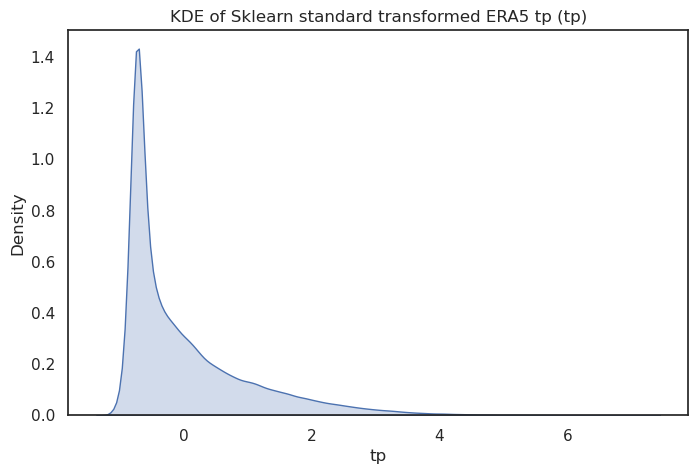

In [10]:
universalKDE('tp', 'Sklearn standard transformed ERA5 tp', scaled_precip)

In [20]:
scaled_precip['tp'].values.min()

np.float32(-1.1308583)

In [21]:
scaled_precip['tp'].values.max()

np.float32(7.207118)

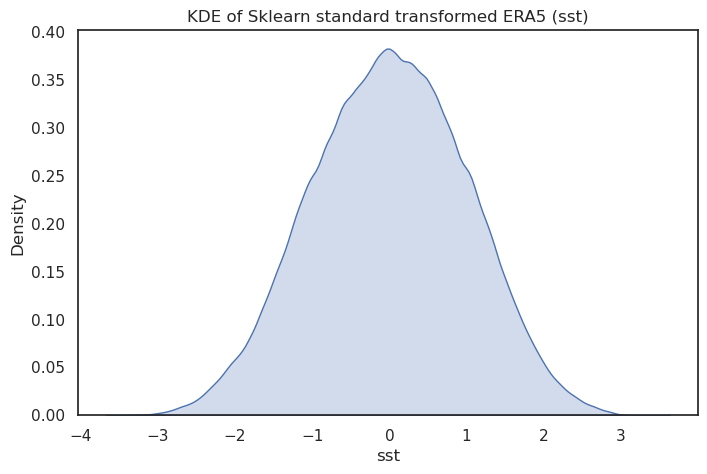

In [13]:
universalKDE('sst', 'Sklearn standard transformed ERA5', scaled_sst)

In [14]:
import numpy as np
import xarray as xr
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def standardizeNC(
    path: str,
    feature_dim: str = None,
    vars_to_scale: list = None,
    scaler_type: str = "standard",      # NEW: "standard" or "minmax"
    minmax_range: tuple = (0, 1)        # Allows custom MinMax scaling range
) -> xr.Dataset:
    """
    Scale variables in a NetCDF file using either StandardScaler (z-score)
    or MinMaxScaler (rescale to given range).
    """

    # Load dataset
    ds = xr.open_dataset(Path(path).expanduser())

    # Ensure vars_to_scale is a list
    if isinstance(vars_to_scale, str):
        vars_to_scale = [vars_to_scale]

    # Auto-select numeric vars
    if vars_to_scale is None:
        vars_to_scale = [
            v for v in ds.data_vars
            if np.issubdtype(ds[v].dtype, np.number)
        ]

    # Infer feature dimension
    if feature_dim is None:
        if "time" in ds.dims:
            feature_dim = "time"
        else:
            candidates = [dim for dim in ds.sizes if ds.sizes[dim] > 1]
            if len(candidates) != 1:
                raise ValueError(
                    "Cannot infer feature dimension automatically. "
                    "Please specify feature_dim explicitly."
                )
            feature_dim = candidates[0]

    # Select scaler type
    if scaler_type.lower() == "standard":
        scaler_class = StandardScaler
        scaler_kwargs = {}
    elif scaler_type.lower() == "minmax":
        scaler_class = MinMaxScaler
        scaler_kwargs = {"feature_range": minmax_range}
    else:
        raise ValueError("scaler_type must be 'standard' or 'minmax'.")

    scaled_data = {}

    # Iterate over variables
    for var in vars_to_scale:
        arr = ds[var]

        # Move feature_dim to leading position
        arr_transposed = arr.transpose(feature_dim, ...)
        orig_shape = arr_transposed.shape

        # Flatten all spatial dims for sklearn
        reshaped = arr_transposed.values.reshape(orig_shape[0], -1)

        # Fit + transform
        scaler = scaler_class(**scaler_kwargs)
        scaled_values = scaler.fit_transform(reshaped)

        # Restore original shape
        scaled_values = scaled_values.reshape(orig_shape)

        # Return to original dim order
        permuted = scaled_values.transpose(
            arr.get_axis_num(feature_dim),
            *[arr.get_axis_num(d) for d in arr.dims if d != feature_dim]
        )

        scaled_da = xr.DataArray(
            permuted,
            coords=arr.coords,
            dims=arr.dims,
            attrs=arr.attrs
        )

        scaled_data[var] = scaled_da

    # Build the output dataset
    scaled_ds = ds.copy()
    for var, da in scaled_data.items():
        scaled_ds[var] = da

    return scaled_ds


In [15]:
mmtp = standardizeNC('~/signal-extraction/vae_input_data/tp_mon-sum.nc', 'valid_time', ['tp'], 'minmax')

In [41]:
mmsst = standardizeNC('~/signal-extraction/vae_input_data/sst_mon-mean.nc', 'valid_time', ['sst'])

In [45]:
universalKDE('tp', 'ERA5 sklearn mm scaled', mmt['tp'].values.log())

/tmp/ipykernel_1447/3987035121.py:1: RuntimeWarning: divide by zero encountered in log
  universalKDE('tp', 'ERA5 sklearn mm scaled', np.log(mmtp['tp'].values))


TypeError: Input must be one of: str (CSV path), DataFrame, Series, xarray.DataArray, or xarray.Dataset.

In [177]:
def ncKDE(var: str, model:str, path: str, log:bool):
    sns.set_theme(style = 'white')
    prdata = xr.open_dataset(f"~/{path}")
    precip = prdata[f"{var}"].values  # shape (time, lat, lon)
    precip_flat = precip.flatten()
    
    # Remove invalids
    precip_flat = precip_flat[~np.isnan(precip_flat)]
    if log == True:
         plotdat = np.log1p(precip_flat)  # log(1 + precip)
    else: plotdat = precip_flat
        
    plt.figure(figsize=(8,5))
    sns.kdeplot(plotdat, fill=True)
    plt.xlabel(f"{var}")
    plt.title(f"KDE of {model} ({var})")
    plt.show()

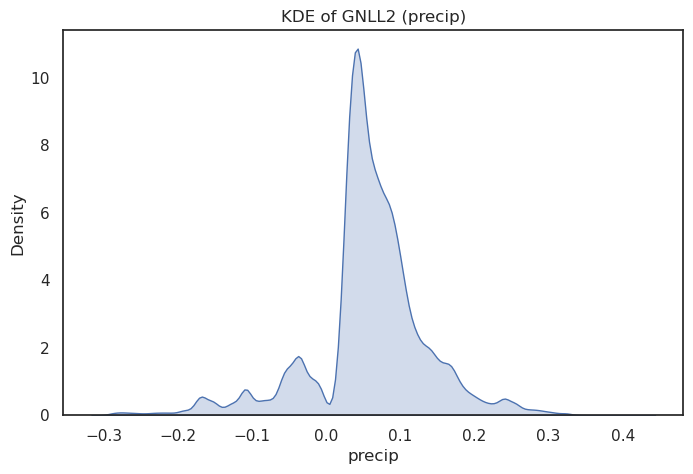

In [178]:
ncKDE('precip','GNLL2','signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_precip.nc', False)

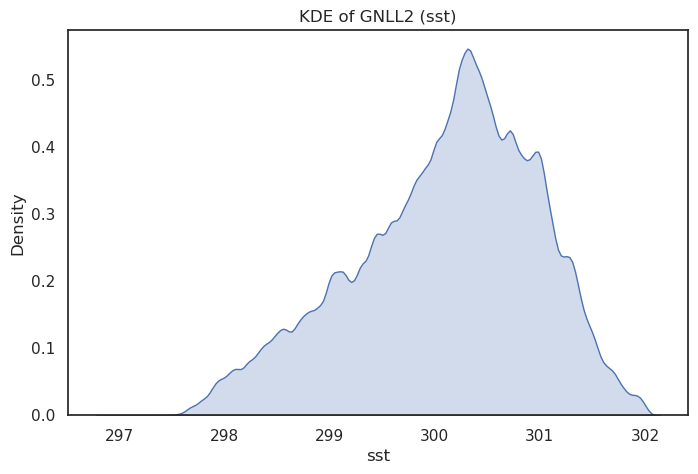

In [181]:
ncKDE('sst','GNLL2','signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_sst.nc', False)

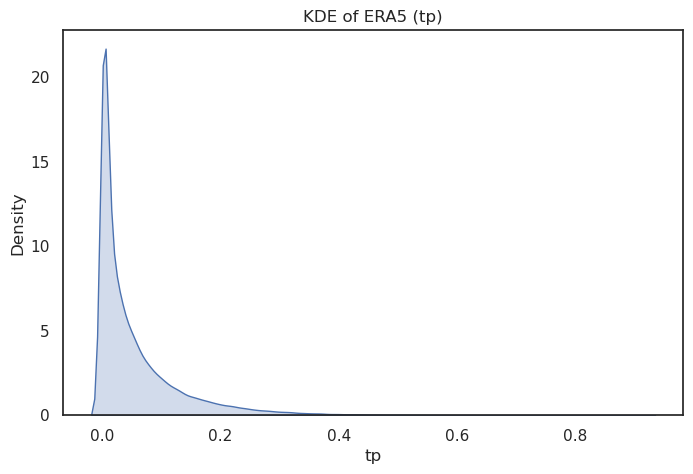

In [180]:
ncKDE('tp', 'ERA5', 'signal-extraction/vae_input_data/tp_mon-sum.nc', False)

In [62]:
pdata = xr.open_dataset("~/signal-extraction/vae_input_data/tp_mon-sum.nc")

In [63]:
pdata

<xarray.Dataset> Size: 1MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 17, longitude: 17)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 136B 40.0 39.75 39.5 ... 36.5 36.25 36.0
  * longitude        (longitude) float64 136B -123.0 -122.8 ... -119.2 -119.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    tp               (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 18:32:56 2025: CDO monsum ../signal-e...
    frequency:               mon
    CDO:                     Climate Data Operators version 2.5.1 (https://mp...

In [ ]:
latentKDE(

In [65]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# ---------------------------
# LOAD AND PREPARE DATA
# ---------------------------

# Extract precipitation as a flattened 1D array
# pdata is your loaded xarray Dataset
precip = pdata["tp"].values  # shape (time, lat, lon)
precip_flat = precip.flatten()

# Remove invalids
precip_flat = precip_flat[~np.isnan(precip_flat)]

# For transformations
precip_log = np.log1p(precip_flat)  # log(1 + precip)


In [66]:
precip_flat

array([2.3085856e-01, 2.0495057e-01, 2.2209692e-01, ..., 1.9073486e-06,
       0.0000000e+00, 8.2969666e-05], shape=(296514,), dtype=float32)

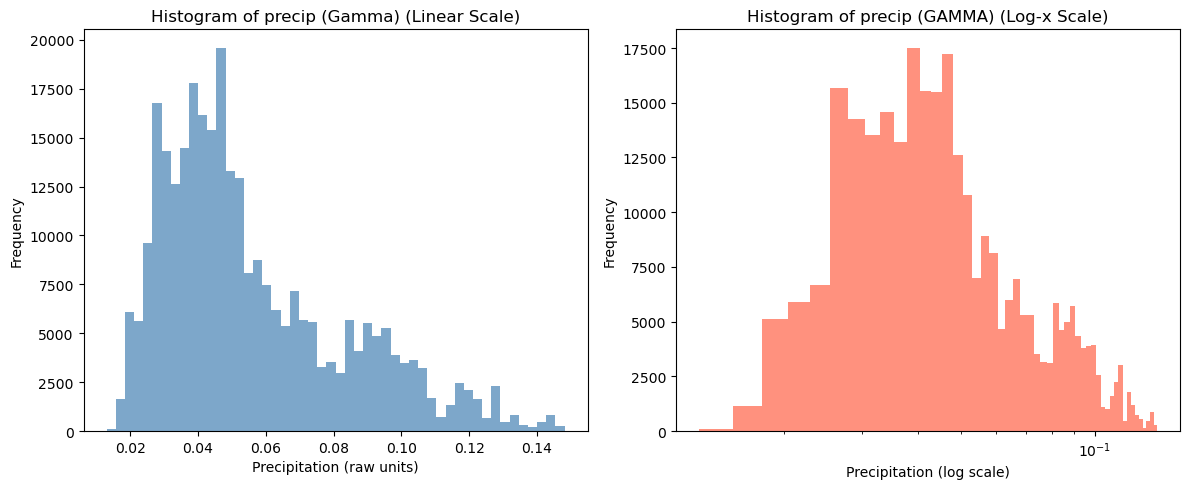

In [6]:

plt.figure(figsize=(12,5))

# Linear histogram
plt.subplot(1,2,1)
plt.hist(precip_flat, bins=50, color='steelblue', alpha=0.7)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("Frequency")
plt.title("Histogram of precip (Gamma) (Linear Scale)")

# Log-x histogram
plt.subplot(1,2,2)
plt.hist(precip_log, bins=50, color='tomato', alpha=0.7)
plt.xscale("log")
plt.xlabel("Precipitation (log scale)")
plt.ylabel("Frequency")
plt.title("Histogram of precip (GAMMA) (Log-x Scale)")

plt.tight_layout()
plt.show()


In [8]:
latent = pd.read_csv("~/signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv")

In [27]:
def latentKDE( var: str, model:str, path: str):
    sns.set_theme(style = 'white')
    latent = pd.read_csv(f"~/{path}")
    plt.figure(figsize=(8,5))
    sns.kdeplot(latent[var].values, fill=True)
    plt.xlabel(f"{var}")
    plt.title(f"KDE of {model} Latent Index ({var})")
    plt.show()

In [28]:
def observedKDE( var: str, model:str, df, log: False):
    sns.set_theme(style = 'white')
    #latent = pd.read_csv(f"~/{path}")
    df
    plt.figure(figsize=(8,5))
    if log == True:
        sns.kdeplot(np.log(df.values), fill=True)
    else: sns.kdeplot(df.values, fill=True)
    plt.xlabel(f"{var}")
    plt.title(f"KDE of {model} ({var})")
    plt.show()

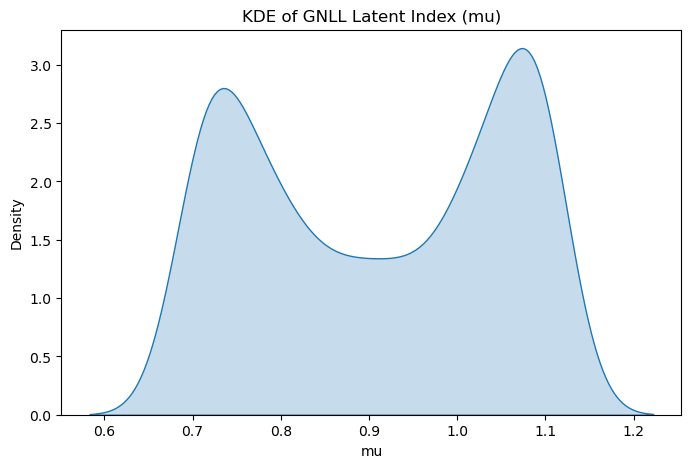

In [27]:
latentKDE('mu','GNLL', 'signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv')

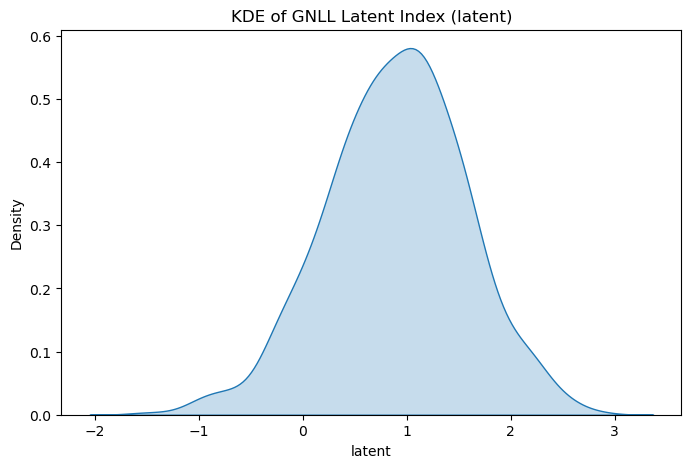

In [28]:
latentKDE('latent','GNLL', 'signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv')

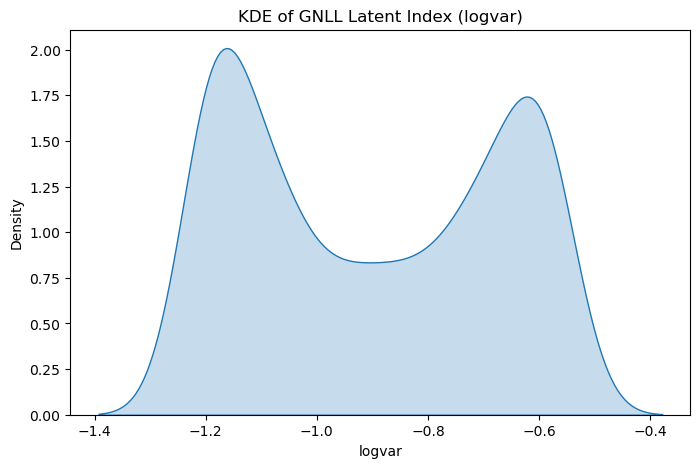

In [29]:
latentKDE('logvar','GNLL', 'signal-extraction/results/ERA5_GNLL/ERA5_GNLL_extractr_results_latent_full.csv')

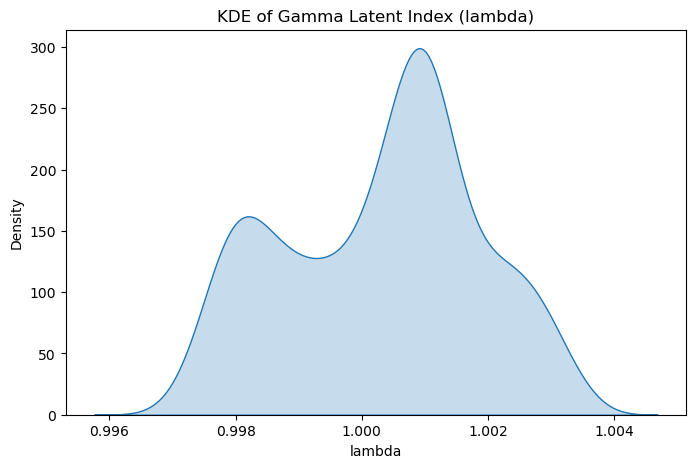

In [21]:
latentKDE('lambda', 'Gamma', 'signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_latent_full.csv')

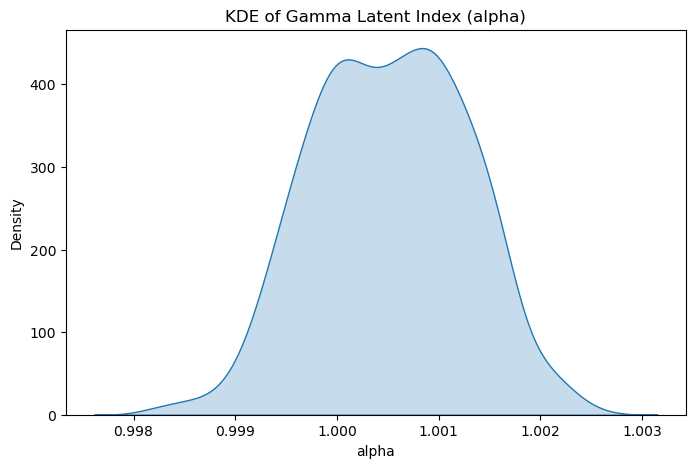

In [31]:
latentKDE('alpha', 'Gamma', 'signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_latent_full.csv')

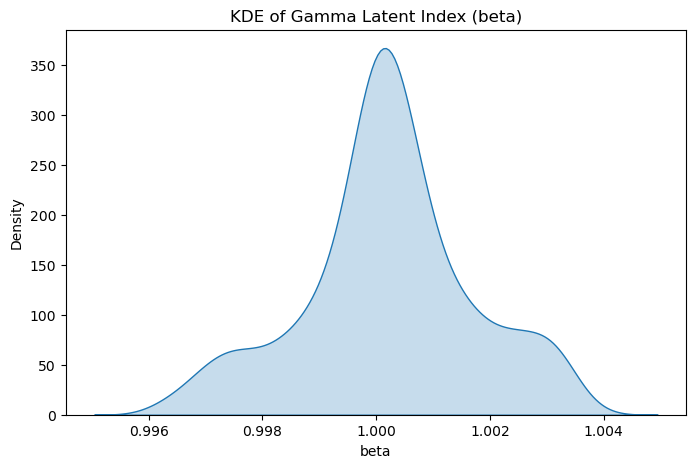

In [32]:
latentKDE('beta', 'Gamma', 'signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_latent_full.csv')

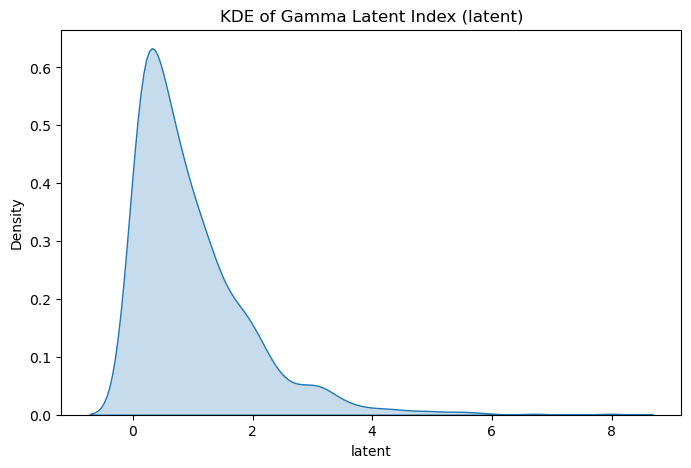

In [33]:
latentKDE('latent', 'Gamma', 'signal-extraction/results/ERA5_GAMMA/ERA5_GAMMA_extractr_results_latent_full.csv')

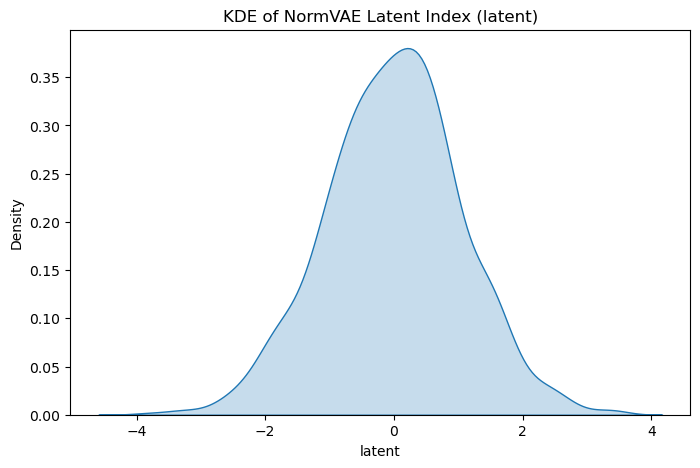

In [22]:
latentKDE('latent','NormVAE', 'signal-extraction/results/ERA5_norm_vae/ERA5_norm_vae_extractr_results_latent_full.csv')

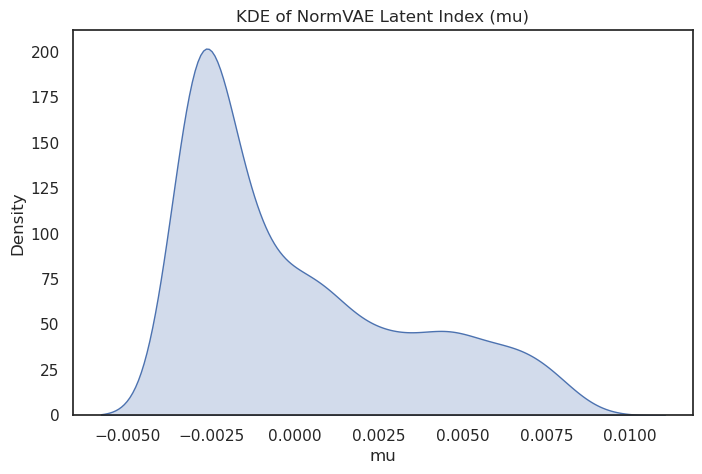

In [31]:
latentKDE('mu','NormVAE', 'signal-extraction/results/ERA5_norm_vae/ERA5_norm_vae_extractr_results_latent_full.csv')

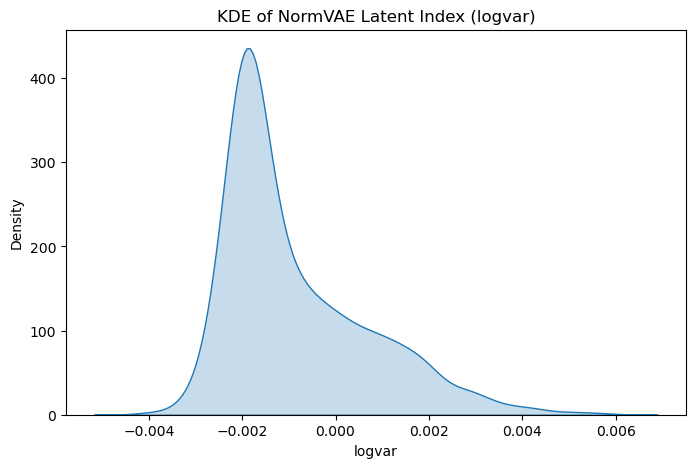

In [30]:
latentKDE('logvar','NormVAE', 'signal-extraction/results/ERA5_norm_vae/ERA5_norm_vae_extractr_results_latent_full.csv')

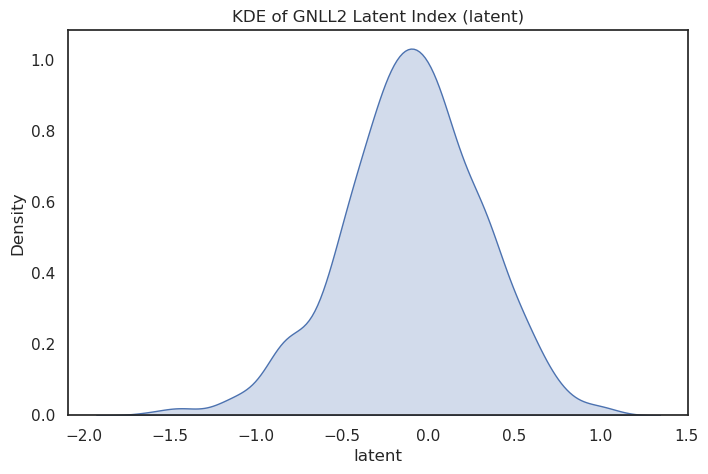

In [171]:
latentKDE('latent', 'GNLL2', 'signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_latent_full.csv')

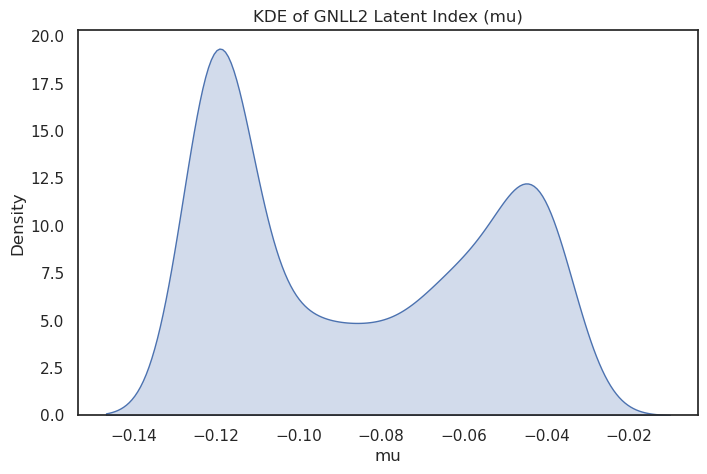

In [172]:
latentKDE('mu', 'GNLL2', 'signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_latent_full.csv')

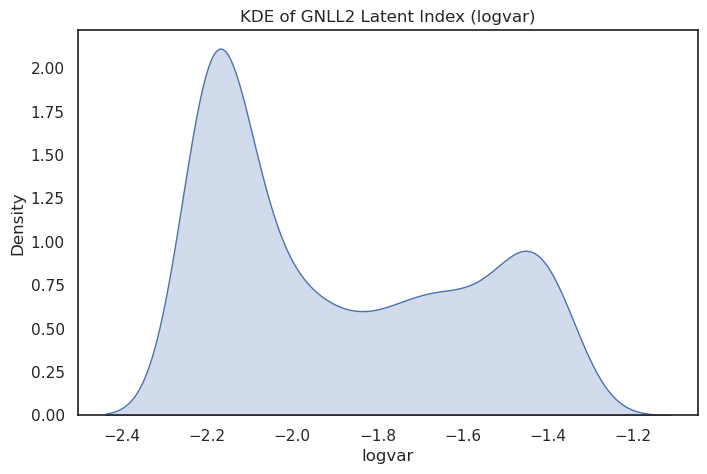

In [173]:
latentKDE('logvar', 'GNLL2', 'signal-extraction/results/ERA5_GNLL2/ERA5_GNLL2_extractr_results_latent_full.csv')

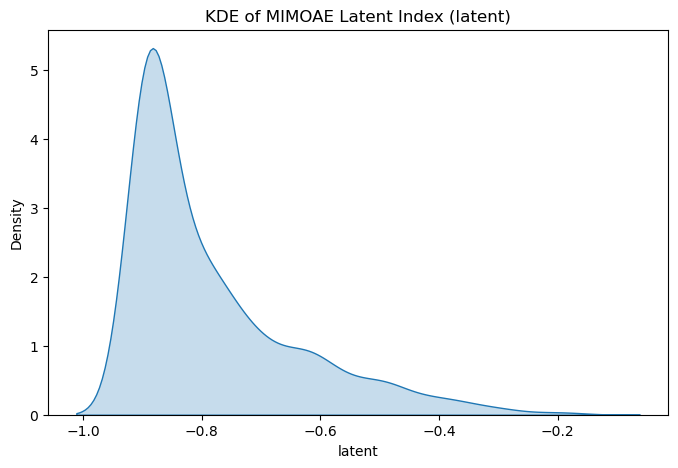

In [23]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

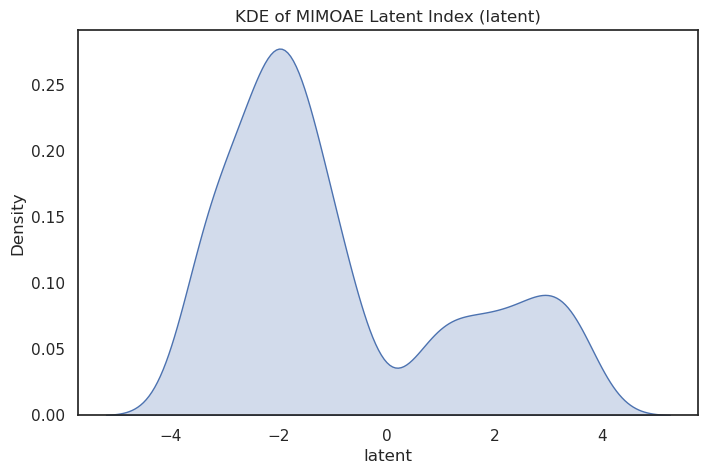

In [22]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-std.csv')

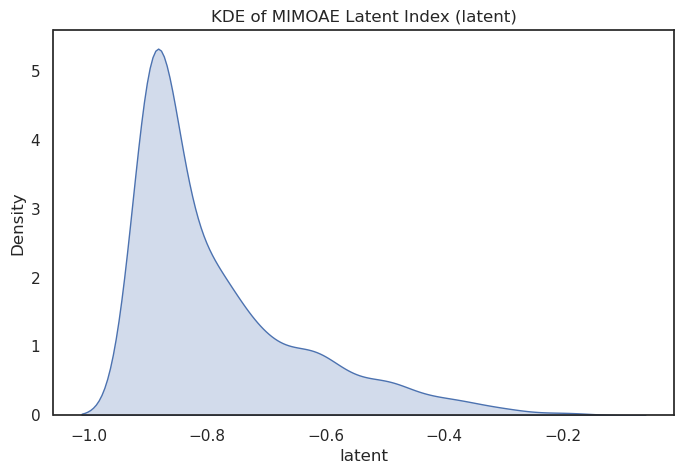

In [38]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

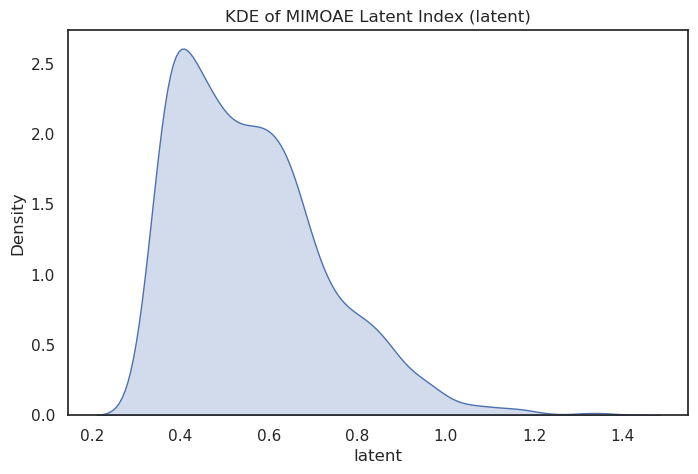

In [24]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-event_duration_tp-mm.csv')

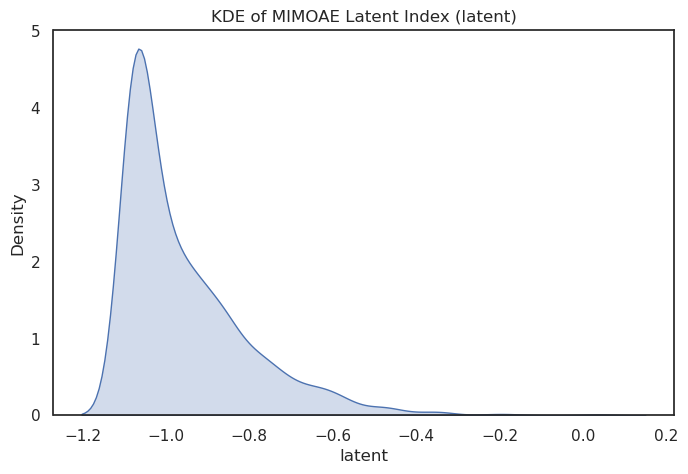

In [26]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_event_intensity_tp-mm.csv')

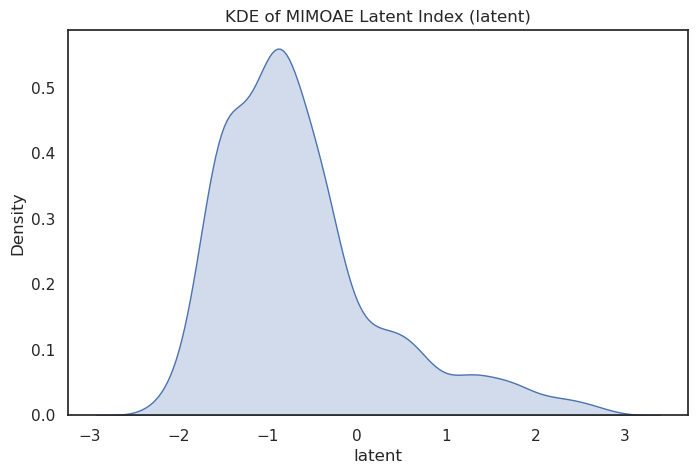

In [27]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_event_intensity_tp-std.csv')

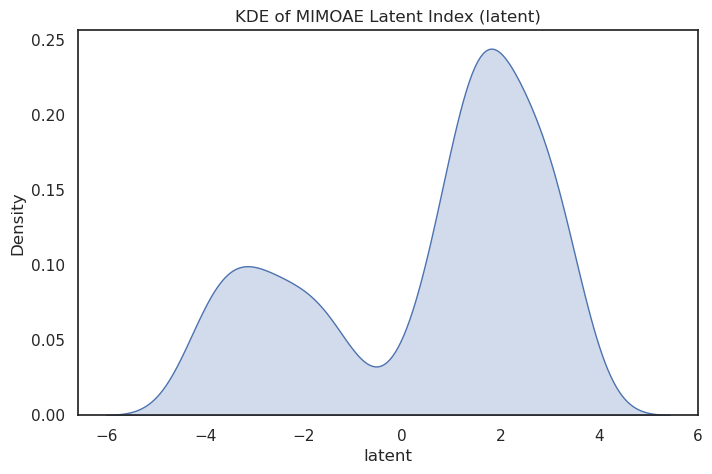

In [32]:
latentKDE('latent','MIMOAE','signal-extraction/results/MIMOAE/mon_mean_sst-mon_max_tp-std.csv')

In [3]:
# Input file information
time_var = 'datetime'  # Time variable name in source file for time series data
var_interest = 'discharge_cfs'
vae_signal = '~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv'
sigvar = 'latent'
site = '11446500' #Site Number: American river at Fair Oaks
parameter_code = '00060' # Discharge (cfs)
start_date = "1904-10-01" # Beginning of record
end_date = "2025-10-01"

# Naming and formatting
data_type = "Streamflow" # Variable name in time series
data_unit = "cfs" # Variable unit in time series
data_source = "ERA5" # Data source, eg. Gauge/location
run_name = "ERA5_GAMMA_Full_KNN" # Name your file output
folder = 'signal-extraction/results/GCM'  # Specify desired output folder
sns.set_theme(style = 'white') # Set theme for all plotting

In [5]:
!pip install dataretrieval
import dataretrieval.nwis as nwis


#Download data 
df = nwis.get_record(sites = site, service = 'dv', start = start_date, end= end_date, parameterCd = parameter_code)
df[var_interest] = df[parameter_code+'_Mean']

# Ensure df index is also timezone-naive
df.index = df.index.tz_localize(None)

# Clip to the SAME date range as signal (inclusive)
#df = df.loc[sig_start:sig_end]

# Resample to annual frequency and take the maximum daily
annual_max = df[var_interest].resample('YE').max()

# Extract the year from each date
years = df.index.year

# Find the unique years
time = np.unique(years)

# Convert the series to a DataFrame
annual_max_df = annual_max.to_frame(name='annual_max_streamflow')

# Identify annual maxima
time_series = annual_max_df['annual_max_streamflow'].values

In [9]:
annual_max

datetime
1904-12-31     11600.0
1905-12-31     21200.0
1906-12-31     44500.0
1907-12-31    105000.0
1908-12-31      7030.0
                ...   
2021-12-31      5050.0
2022-12-31      9760.0
2023-12-31     32500.0
2024-12-31      6360.0
2025-12-31      7730.0
Freq: YE-DEC, Name: discharge_cfs, Length: 122, dtype: float64

In [17]:
annual_max_df.min()

annual_max_streamflow    1300.0
dtype: float64

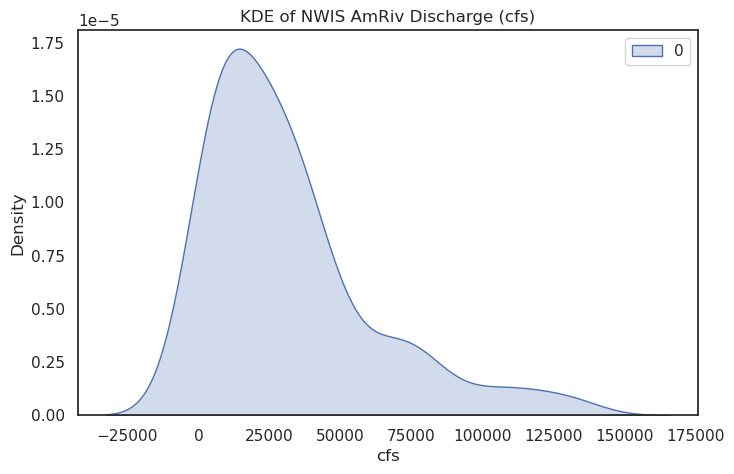

In [79]:
observedKDE('cfs','NWIS AmRiv Discharge',annual_max_df, False)

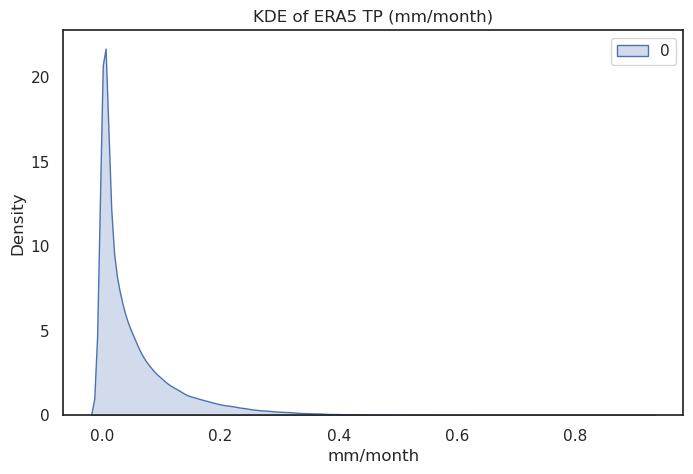

In [78]:
observedKDE('mm/month','ERA5 TP', pd.DataFrame(precip_flat), False)

In [88]:
from scipy.stats import gamma

shape_hat, loc_hat, scale_hat = gamma.fit(annual_max_df.values)

In [89]:
print(f"shape: {shape_hat}, location: {loc_hat}, scale: {scale_hat}")

shape: 0.7957901772182723, location: 1299.9999999999998, scale: 34911.35470323652


In [47]:
print(f"mean: {annual_max_df.values.mean()}, min: {annual_max_df.values.min()}, max:{annual_max_df.values.max()}, var: {annual_max_df.values.var()}")

mean: 31745.90163934426, min: 1300.0, max:132000.0, var: 864777056.9739319


In [86]:
pshape_hat, ploc_hat, pscale_hat = gamma.fit(precip_flat)

In [87]:
print(f"shape: {pshape_hat}, location: {ploc_hat}, scale: {pscale_hat}")

shape: 0.45851671083399625, location: -1.6204054110090576e-31, scale: 0.11012469500517749


In [7]:
time_series

array([ 11600.,  21200.,  44500., 105000.,   7030.,  98000.,  21700.,
        69100.,  11300.,  38800.,  57700.,  41800.,  33200.,  37600.,
        12400.,  45000.,  18800.,  32800.,  29800.,  24800.,  10600.,
        68200.,  22700.,  48200., 119000.,  14800.,  18800.,  17500.,
        18900.,  12700.,  13300.,  49300.,  46400.,  81100.,  33400.,
         8500.,  69600.,  26900.,  54600.,  73800.,  12400.,  70900.,
        13300.,  20100.,  17600.,  25500., 132000.,  39500.,  30500.,
        27600.,  36500.,  69300.,  33500.,  28200.,  33000.,   6260.,
         5170.,   4540.,   7870.,  74100., 115000.,  35500.,  22600.,
        35900.,   8230.,  67200.,  52200.,   8240.,   5270.,  31900.,
        26400.,   8250.,   3070.,   1300.,  15200.,  16000.,  80200.,
        36100.,  84200.,  47200.,  19600.,   4110., 131000.,   3500.,
         4550.,  24400.,   7930.,   4440.,   4670.,  16100.,   4090.,
        41800.,  43700., 106000.,  33700.,  23900.,  24100.,   3110.,
         4020.,   70

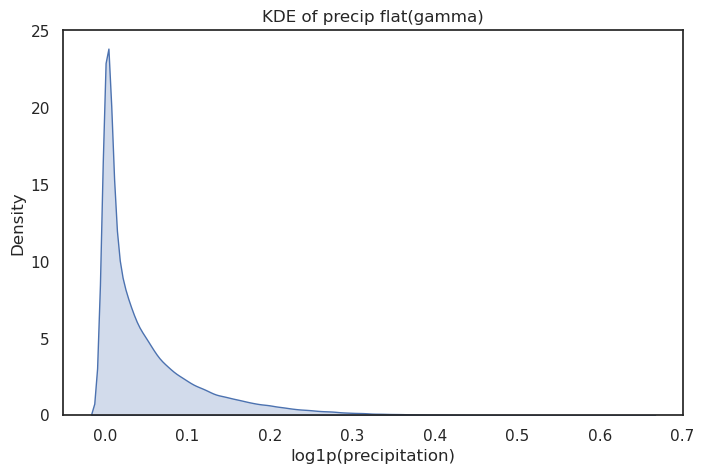

In [91]:
plt.figure(figsize=(8,5))
sns.kdeplot(precip_log, fill=True)
plt.xlabel("log1p(precipitation)")
plt.title("KDE of precip flat(gamma)")
plt.show()

In [162]:
from scipy.stats import pearson3

In [163]:
y = np.log10(annual_max)

shape, loc, scale = pearson3.fit(y)

In [165]:
print(f"shape:{shape}, loc:{loc}, scale:{scale}")

shape:-0.6422030778690299, loc:4.302411365620529, scale:0.45635542731661416


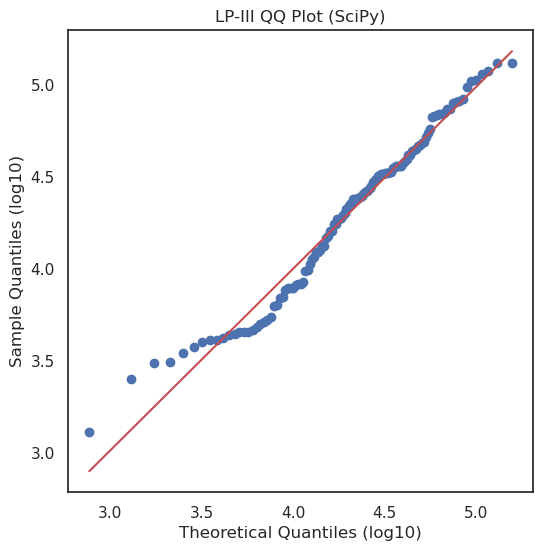

In [169]:
plt.figure(figsize=(6,6))
probplot(y, dist=pearson3, sparams=(shape, loc, scale), plot=plt)
plt.title("LP-III QQ Plot (SciPy)")
plt.xlabel("Theoretical Quantiles (log10)")
plt.ylabel("Sample Quantiles (log10)")
plt.show()

((array([1.30000001e+03, 1.30000003e+03, 1.30000007e+03, 1.30000014e+03,
         1.30000023e+03, 1.30000037e+03, 1.30000054e+03, 1.30000078e+03,
         1.30000108e+03, 1.30000146e+03, 1.30000195e+03, 1.30000256e+03,
         1.30000332e+03, 1.30000425e+03, 1.30000540e+03, 1.30000679e+03,
         1.30000848e+03, 1.30001052e+03, 1.30001298e+03, 1.30001592e+03,
         1.30001945e+03, 1.30002365e+03, 1.30002866e+03, 1.30003461e+03,
         1.30004166e+03, 1.30005002e+03, 1.30005989e+03, 1.30007155e+03,
         1.30008530e+03, 1.30010150e+03, 1.30012057e+03, 1.30014300e+03,
         1.30016937e+03, 1.30020035e+03, 1.30023673e+03, 1.30027943e+03,
         1.30032956e+03, 1.30038838e+03, 1.30045739e+03, 1.30053837e+03,
         1.30063340e+03, 1.30074493e+03, 1.30087585e+03, 1.30102958e+03,
         1.30121017e+03, 1.30142239e+03, 1.30167192e+03, 1.30196547e+03,
         1.30231105e+03, 1.30271816e+03, 1.30319813e+03, 1.30376447e+03,
         1.30443335e+03, 1.30522411e+03, 1.30615995

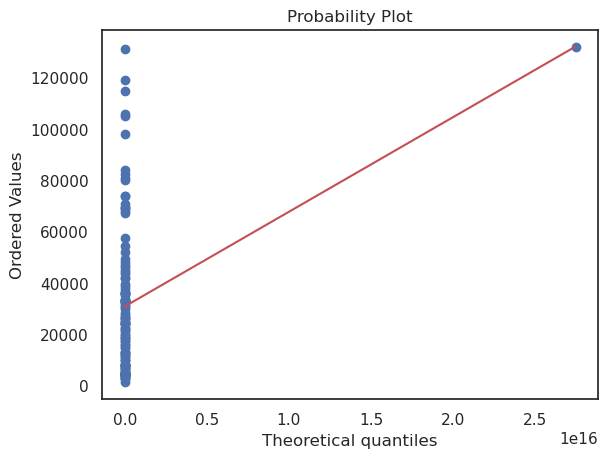

In [154]:
from scipy.stats import genextreme as gev

shape, loc, scale = gev.fit(annual_max)
probplot(annual_max, dist=gev, sparams=(shape, loc, scale), plot=plt)

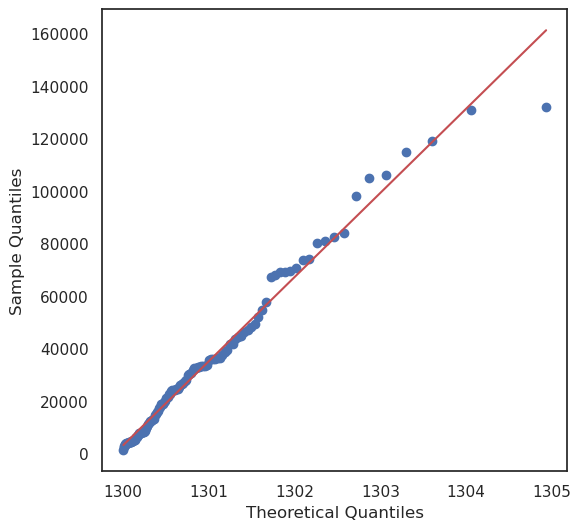

In [153]:
plt.figure(figsize=(6,6))
probplot(annual_max, dist="gamma", sparams=(0.9,1300), plot=plt)
plt.title("")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

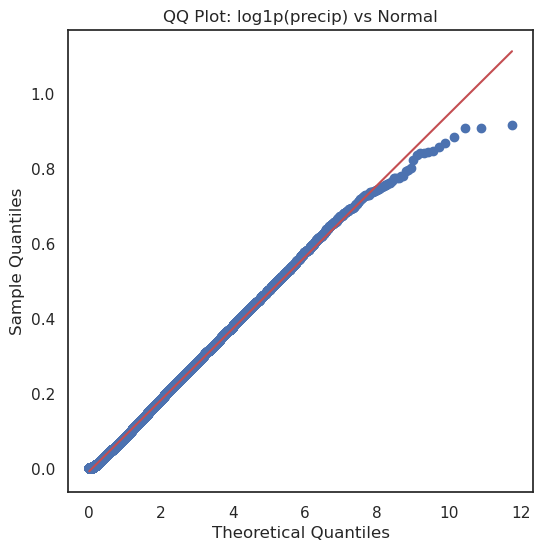

In [150]:
plt.figure(figsize=(6,6))
probplot(precip_flat, dist="gamma", sparams=(0.65,0), plot=plt)
plt.title("QQ Plot: log1p(precip) vs Normal")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

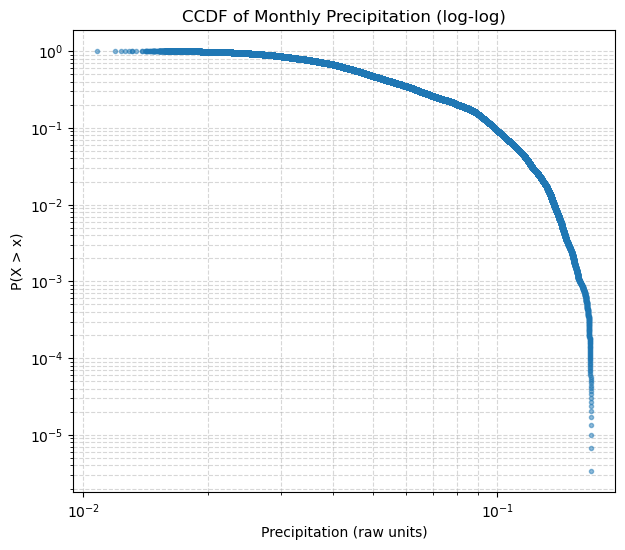

In [26]:
# Sort data
sorted_precip = np.sort(precip_flat)

# CCDF = P(X > x)
ccdf = 1.0 - np.arange(1, len(sorted_precip)+1) / len(sorted_precip)

plt.figure(figsize=(7,6))
plt.loglog(sorted_precip, ccdf, marker='.', linestyle='none', alpha=0.5)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Monthly Precipitation (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


In [46]:
import xarray as xr

In [47]:
sdata1 = xr.open_dataset("~/signal-extraction/vae_input_data/ERA5_pr_dat/1998.nc")

In [50]:
inputprip= xr.open_dataset("~/signal-extraction/vae_input_data/tp_mon-sum.nc")

In [54]:
prip_mean = inputprip['tp'].values.mean()

In [53]:
prip_var = inputprip['tp'].values.var()

In [57]:
alpha = (prip_mean*prip_mean)/prip_var
alpha

np.float32(0.5003716)

In [58]:
beta = (prip_mean/prip_var)
beta

np.float32(9.176744)

In [62]:
mimo_latent = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

In [65]:
lmean = mimo_latent['latent'].values.mean()
lvar = mimo_latent['latent'].values.var()

In [69]:
lalpha=(lmean*lmean)/lvar
lalpha

np.float64(30.38926529698923)

In [71]:
lbeta=(lmean/lvar)
lbeta

np.float64(-38.80438274565291)

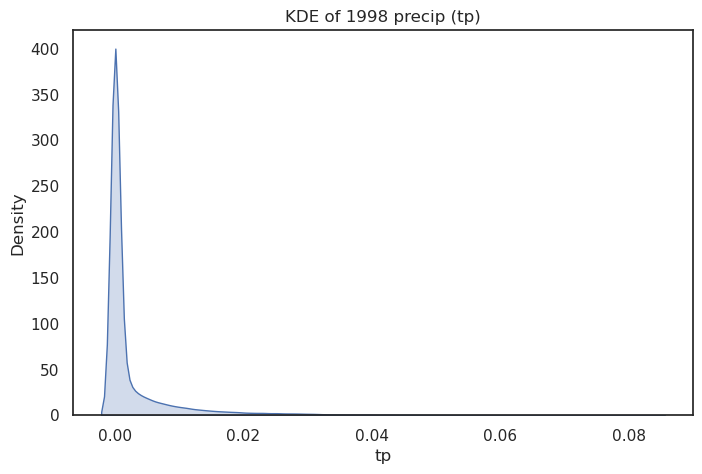

In [49]:
universalKDE('tp', '1998 precip', sdata1)